# Count Sketch: A Standalone Tutorial

Count Sketch is a randomized way to compress a high-dimensional vector into a much smaller table. Each coordinate is sent to a few randomly chosen buckets with random signs. To recover a coordinate, we read back its buckets, undo the signs, and take a median. This is useful when the original vector is too expensive to transmit, store, or aggregate directly.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Let the notebook import src/sketch.py when run from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.sketch import CountSketch

np.random.seed(42)
torch.manual_seed(42)


In [ ]:
# Create a sparse synthetic vector with a few large "heavy hitter" entries.
vector_dim = 80_000
num_heavy = 500

vector = torch.zeros(vector_dim)
heavy_idx = np.random.choice(vector_dim, size=num_heavy, replace=False)
vector[heavy_idx] = torch.randn(num_heavy) * 10

# Add small background noise so the problem is more realistic.
vector += torch.randn(vector_dim)
print(f"Vector length: {vector_dim}, nonzero-ish heavy entries: {num_heavy}")


Vector length: 1000000, nonzero-ish heavy entries: 1000


## Compressing by about 25x

We will compress a length-1,000,000 vector into a Count Sketch that stores roughly 40,000 numbers total. Recovery will not be exact because many coordinates collide in the same buckets, but the heavy entries should remain recognizable.

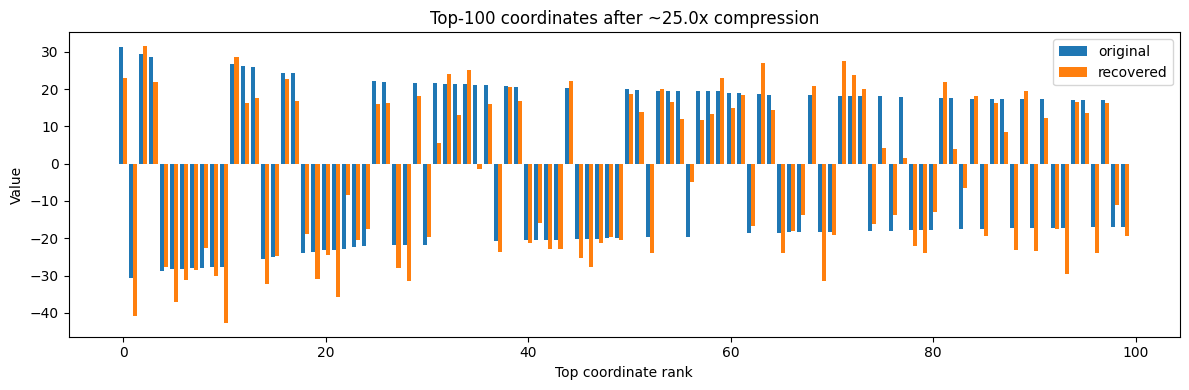

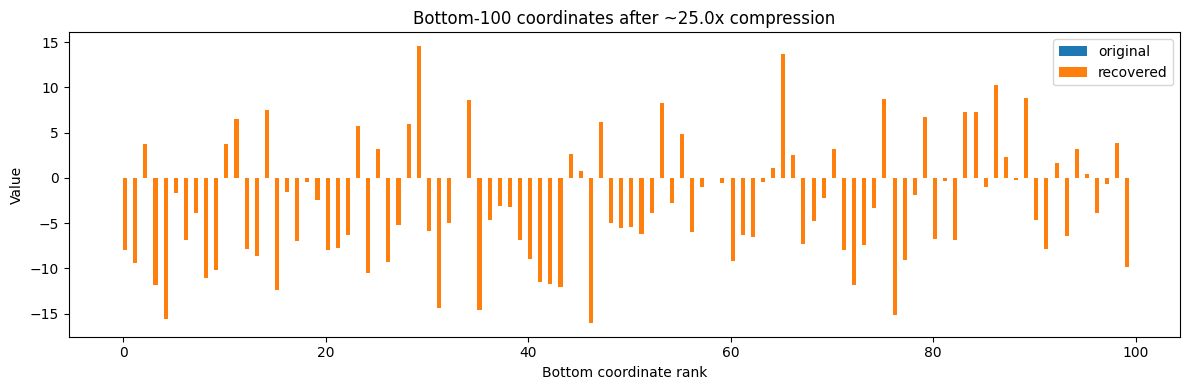

In [28]:
rows = 10
target_ratio = 25
width = vector_dim // (rows * target_ratio)

sketcher = CountSketch(rows, width, vector_dim, seed=0)
sketch_matrix = sketcher.sketch(vector)
recovered = sketcher.unsketch(sketch_matrix)

top_idx = torch.topk(vector.abs(), k=100).indices

bottom_idx = torch.topk(vector.abs(), k=100, largest=False).indices

x = np.arange(100)

plt.figure(figsize=(12, 4))
plt.bar(x - 0.2, vector[top_idx], width=0.4, label="original")
plt.bar(x + 0.2, recovered[top_idx], width=0.4, label="recovered")
plt.title(f"Top-100 coordinates after ~{sketcher.compression_ratio():.1f}x compression")
plt.xlabel("Top coordinate rank")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(x - 0.2, vector[bottom_idx], width=0.4, label="original")
plt.bar(x + 0.2, recovered[bottom_idx], width=0.4, label="recovered")
plt.title(f"Bottom-100 coordinates after ~{sketcher.compression_ratio():.1f}x compression")
plt.xlabel("Bottom coordinate rank")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


## Linearity

Count Sketch is linear: sketching `a` and `b` separately and adding the sketches gives the same sketch matrix as sketching `a + b`. In federated learning, this lets a server average compressed client updates directly in sketch space.

In [29]:
a = torch.randn(vector_dim)
b = torch.randn(vector_dim)

sketch_a = sketcher.sketch(a)
sketch_b = sketcher.sketch(b)

from_summed_sketches = sketcher.unsketch(sketch_a + sketch_b)
from_true_sum_sketch = sketcher.unsketch(sketcher.sketch(a + b))
true_sum = a + b

print("||unsketch(S(a)+S(b)) - unsketch(S(a+b))||:",
      torch.norm(from_summed_sketches - from_true_sum_sketch).item())
print("||unsketch(S(a)+S(b)) - (a+b)||:",
      torch.norm(from_summed_sketches - true_sum).item())
print("||a+b||:",
      torch.norm(true_sum).item())


||unsketch(S(a)+S(b)) - unsketch(S(a+b))||: 0.007035700138658285
||unsketch(S(a)+S(b)) - (a+b)||: 9213.0771484375
||a+b||: 1414.685791015625


## How sketch size affects error

Wider sketches have fewer collisions, so recovery error should generally decrease as we store more buckets. The next cell varies width and plots L2 recovery error against the implied compression ratio.

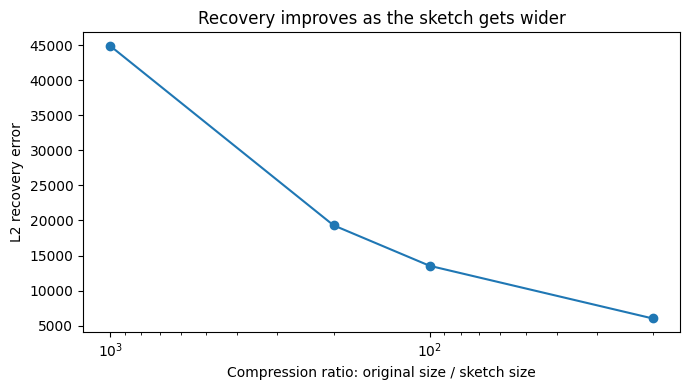

In [33]:
rows = 10
widths = [100, 500, 1000, 5000]
ratios = []
errors = []

for width in widths:
    cs = CountSketch(rows, width, vector_dim, seed=42)
    estimate = cs.unsketch(cs.sketch(vector))
    ratios.append(cs.compression_ratio())
    errors.append(torch.norm(estimate - vector).item())

plt.figure(figsize=(7, 4))
plt.plot(ratios, errors, marker="o")
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Compression ratio: original size / sketch size")
plt.ylabel("L2 recovery error")
plt.title("Recovery improves as the sketch gets wider")
plt.tight_layout()
plt.show()


## Summary

Count Sketch gives a simple way to compress vectors that may contain both positive and negative values, such as gradients or neural-network parameter updates. Its linearity is what makes it especially convenient for federated learning: clients can send sketches, the server can average those sketches, and the final reconstruction approximates the average update.